<h1 style="text-align:center;">Clean and Explore 2024 Presidential Election Data in Colorado</h1>

In [ ]:
#import sys
#!{sys.executable} -m pip install geopandas

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
print(gpd.__version__)

1.1.3


## Data
Polling station, dropbox and early voting location information:
https://geodata.colorado.gov/datasets/0b26c8161c1e4597816b107f0dba0d15_0/explore?location=39.934750%2C-102.798471%2C6

2024 presidential election results: 
https://demography.dola.colorado.gov/assets/html/county.html

2024 voting results:
https://results.enr.clarityelections.com/CO/122598/web.345435/#/summary

File for map data: 
https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html

### Import Colorado Polling Locations Dataset

In [2]:
# Polling locations dataset
loc_df = pd.read_csv("data/Colorado_Polling_Locations_2025.csv")
loc_df.head()

,X,Y,county,site_type,site_availability,site_info,name,address_line1,address_line2,address_city,...,sh_10_27,sh_10_28,sh_10_29,sh_10_30,sh_10_31,sh_11_1,sh_11_2,sh_11_3,sh_11_4,OBJECTID
0,-1.162854e+07,4.771434e+06,Elbert,dropbox,10/14/2025 to 11/04/2025,24-hour dropbox,Elbert County Elections Office,440 Comanche Street,NaN,Kiowa,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,-1.164366e+07,4.773512e+06,Elbert,dropbox,10/14/2025 to 11/04/2025,24-hour dropbox,Elizabeth Town Hall,151 S Banner Street,NaN,Elizabeth,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
2,-1.164897e+07,4.788523e+06,Elbert,dropbox,10/14/2025 to 11/04/2025,24-hour dropbox,Elbert County Road & Bridge,41082 Firehouse Street,NaN,Parker,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
3,-1.171530e+07,4.642090e+06,Fremont,early vote,10/27/2025 to 11/03/2025,9:00AM-5:00PM M-F,Garden Park,201 N 6th St,NaN,Canon City,...,NaN,NaN,NaN,NaN,NaN,9:00AM-1:00PM,NaN,NaN,NaN,4
4,-1.171530e+07,4.642090e+06,Fremont,polling location,11/04/2025,7:00AM-7:00PM Election Day,Garden Park,201 N 6th St,NaN,Canon City,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5


In [3]:
print(loc_df["site_type"].value_counts())
print(loc_df["county"].unique())

site_type
dropbox             435
polling location    150
early vote          147
drop off             28
drop box              2
Polling Location      2
Drop Box              2
Early vote            1
Name: count, dtype: int64
['Elbert' 'Fremont' 'Garfield ' 'GILPIN' 'Grand' 'Gunnison' 'Hinsdale'
 'Huerfano' 'Jackson' 'Jefferson' 'Kiowa' 'Kit Carson  County'
 'La Plata County ' 'Lake' 'Larimer' 'Las Animas' 'Lincoln' 'Logan' 'Mesa'
 'Mineral' 'Moffat' 'Montezuma' 'Montrose' 'Morgan' 'Otero' 'Ouray' 'Park'
 'Phillips' 'Pitkin' 'Prowers' 'Pueblo' 'Rio Blanco' 'Rio Grande' 'Routt'
 'Saguache' 'San Juan' 'San Miguel' 'Sedgwick' 'Summit' 'Teller'
 'Washington' 'Weld' 'Yuma ' 'Adams' 'Alamosa' 'Arapahoe' 'Archuleta'
 'Baca' 'Bent' 'Boulder' 'Broomfield' 'Chaffee' 'Cheyenne' 'Clear Creek'
 'Conejos' 'Costilla' 'Crowley' 'Custer' 'Delta' 'Denver' 'Dolores'
 'Douglas' 'Eagle' 'El Paso']


### Clean Colorado Polling Locations Dataset

In [4]:
# Drop unnecessary columns
loc_columns_to_drop = [4,5,6,7,8,9,10,11,12,13,14,16,17,18,19,20,21,22,23,24,
                       25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42]
                       
loc_df = loc_df.drop(columns=loc_df.columns[loc_columns_to_drop])

# Normalize formatting of site_type entries
loc_df["site_type"] = (loc_df["site_type"].str.strip().str.lower())
site_mapping = {
    "dropbox": "dropbox",
    "drop box": "dropbox",
    "drop off": "dropbox",
    
    "polling location": "polling location",
    
    "early vote": "early vote"
}
loc_df["site_type"] = loc_df["site_type"].replace(site_mapping)

# Rename county "GILPIN" to "Gilpin" and remove county from "Kit Carson  County" to match formatting 
county_mapping = {
    "Garfield ": "Garfield",
    "Yuma ": "Yuma",
    "GILPIN": "Gilpin",
    "Kit Carson  County": "Kit Carson",
    "La Plata County ": "La Plata"
}
    
loc_df["county"] = loc_df["county"].replace(county_mapping)

loc_df.head()

,X,Y,county,site_type,geocoded_address
0,-1.162854e+07,4.771434e+06,Elbert,dropbox,"440 Comanche St, Kiowa, Colorado, 80117"
1,-1.164366e+07,4.773512e+06,Elbert,dropbox,"151 S Banner St, Elizabeth, Colorado, 80107"
2,-1.164897e+07,4.788523e+06,Elbert,dropbox,"41082 Firehouse St, Parker, Colorado, 80138"
3,-1.171530e+07,4.642090e+06,Fremont,early vote,"201 N 6th St, Canon City, Colorado, 81212"
4,-1.171530e+07,4.642090e+06,Fremont,polling location,"201 N 6th St, Canon City, Colorado, 81212"


In [5]:
print(loc_df["site_type"].value_counts())
print(loc_df["county"].unique())

site_type
dropbox             467
polling location    152
early vote          148
Name: count, dtype: int64
['Elbert' 'Fremont' 'Garfield' 'Gilpin' 'Grand' 'Gunnison' 'Hinsdale'
 'Huerfano' 'Jackson' 'Jefferson' 'Kiowa' 'Kit Carson' 'La Plata' 'Lake'
 'Larimer' 'Las Animas' 'Lincoln' 'Logan' 'Mesa' 'Mineral' 'Moffat'
 'Montezuma' 'Montrose' 'Morgan' 'Otero' 'Ouray' 'Park' 'Phillips'
 'Pitkin' 'Prowers' 'Pueblo' 'Rio Blanco' 'Rio Grande' 'Routt' 'Saguache'
 'San Juan' 'San Miguel' 'Sedgwick' 'Summit' 'Teller' 'Washington' 'Weld'
 'Yuma' 'Adams' 'Alamosa' 'Arapahoe' 'Archuleta' 'Baca' 'Bent' 'Boulder'
 'Broomfield' 'Chaffee' 'Cheyenne' 'Clear Creek' 'Conejos' 'Costilla'
 'Crowley' 'Custer' 'Delta' 'Denver' 'Dolores' 'Douglas' 'Eagle' 'El Paso']


### Import Colorado Population by County Dataset

In [6]:
# Colorado population by county dataset
pop_df = pd.read_excel("data/CountyRankings.xlsx")
pop_df.head()

,County FIPS,Area,July 2010,July 2020,July 2021,July 2022,July 2023,July 2024,2024 rank
0,0,COLORADO STATE,5050332,5786877,5813551,5850121,5900420,5956729,NaN
1,1,ADAMS COUNTY,443711,520489,523505,528201,535901,543760,5.0
2,3,ALAMOSA COUNTY,15474,16373,16577,16593,16650,16632,30.0
3,5,ARAPAHOE COUNTY,574819,655288,656858,658069,661564,666557,3.0
4,7,ARCHULETA COUNTY,12060,13429,13815,13993,14182,14137,34.0


### Clean Population Dataset

In [7]:
# drop first row which is total population of the state
pop_df = pop_df.iloc[1:]

# drop columns with counts other than most recent July 2024
pop_columns_to_drop = [0,2,3,4,5,6,8]
pop_df = pop_df.drop(columns=pop_df.columns[pop_columns_to_drop])

# Rename Area 'county' 
pop_df = pop_df.rename(columns={'Area': 'county', 'July 2024': 'population'})

# Remove 'COUNTY' from county entries to match datasets
pop_df['county'] = pop_df['county'].str.replace(' COUNTY', '')

# Convert county entries to all lowercase except for first letter to match datasets
pop_df['county'] = pop_df['county'].str.title()

pop_df.head()

,county,population
1,Adams,543760
2,Alamosa,16632
3,Arapahoe,666557
4,Archuleta,14137
5,Baca,3398


In [8]:
print(pop_df.isnull().sum())
print(pop_df['county'].unique())

county        0
population    0
dtype: int64
['Adams' 'Alamosa' 'Arapahoe' 'Archuleta' 'Baca' 'Bent' 'Boulder'
 'Broomfield' 'Chaffee' 'Cheyenne' 'Clear Creek' 'Conejos' 'Costilla'
 'Crowley' 'Custer' 'Delta' 'Denver' 'Dolores' 'Douglas' 'Eagle' 'Elbert'
 'El Paso' 'Fremont' 'Garfield' 'Gilpin' 'Grand' 'Gunnison' 'Hinsdale'
 'Huerfano' 'Jackson' 'Jefferson' 'Kiowa' 'Kit Carson' 'Lake' 'La Plata'
 'Larimer' 'Las Animas' 'Lincoln' 'Logan' 'Mesa' 'Mineral' 'Moffat'
 'Montezuma' 'Montrose' 'Morgan' 'Otero' 'Ouray' 'Park' 'Phillips'
 'Pitkin' 'Prowers' 'Pueblo' 'Rio Blanco' 'Rio Grande' 'Routt' 'Saguache'
 'San Juan' 'San Miguel' 'Sedgwick' 'Summit' 'Teller' 'Washington' 'Weld'
 'Yuma']


### Merge Population and Polling Station Datasets

In [9]:
# Merge datasets
pop_loc_df = pd.merge(loc_df, pop_df, on='county', how='left')
pop_loc_df.head()

,X,Y,county,site_type,geocoded_address,population
0,-1.162854e+07,4.771434e+06,Elbert,dropbox,"440 Comanche St, Kiowa, Colorado, 80117",29337
1,-1.164366e+07,4.773512e+06,Elbert,dropbox,"151 S Banner St, Elizabeth, Colorado, 80107",29337
2,-1.164897e+07,4.788523e+06,Elbert,dropbox,"41082 Firehouse St, Parker, Colorado, 80138",29337
3,-1.171530e+07,4.642090e+06,Fremont,early vote,"201 N 6th St, Canon City, Colorado, 81212",50071
4,-1.171530e+07,4.642090e+06,Fremont,polling location,"201 N 6th St, Canon City, Colorado, 81212",50071


In [10]:
print(pop_loc_df.isnull().sum())
print(pop_loc_df['county'].unique())

X                   0
Y                   0
county              0
site_type           0
geocoded_address    0
population          0
dtype: int64
['Elbert' 'Fremont' 'Garfield' 'Gilpin' 'Grand' 'Gunnison' 'Hinsdale'
 'Huerfano' 'Jackson' 'Jefferson' 'Kiowa' 'Kit Carson' 'La Plata' 'Lake'
 'Larimer' 'Las Animas' 'Lincoln' 'Logan' 'Mesa' 'Mineral' 'Moffat'
 'Montezuma' 'Montrose' 'Morgan' 'Otero' 'Ouray' 'Park' 'Phillips'
 'Pitkin' 'Prowers' 'Pueblo' 'Rio Blanco' 'Rio Grande' 'Routt' 'Saguache'
 'San Juan' 'San Miguel' 'Sedgwick' 'Summit' 'Teller' 'Washington' 'Weld'
 'Yuma' 'Adams' 'Alamosa' 'Arapahoe' 'Archuleta' 'Baca' 'Bent' 'Boulder'
 'Broomfield' 'Chaffee' 'Cheyenne' 'Clear Creek' 'Conejos' 'Costilla'
 'Crowley' 'Custer' 'Delta' 'Denver' 'Dolores' 'Douglas' 'Eagle' 'El Paso']


### Import Voting by Colorado County Dataset

In [11]:
# Voting dataset
votes_df = pd.read_excel("data/detail.xlsx", sheet_name='2', header=[0,1])
original_columns = votes_df.columns.tolist()
original_columns
# votes_df.head()

[('Unnamed: 0_level_0', 'County'),
 ('Unnamed: 1_level_0', 'Registered Voters'),
 ('Kamala D. Harris / Tim Walz', 'Election Day Total Votes'),
 ('Kamala D. Harris / Tim Walz', 'Total Votes'),
 ('Donald J. Trump / JD Vance', 'Election Day Total Votes'),
 ('Donald J. Trump / JD Vance', 'Total Votes'),
 ('Blake Huber / Andrea Denault', 'Election Day Total Votes'),
 ('Blake Huber / Andrea Denault', 'Total Votes'),
 ('Chase Russell Oliver / Mike ter Maat', 'Election Day Total Votes'),
 ('Chase Russell Oliver / Mike ter Maat', 'Total Votes'),
 ('Jill Stein / Rudolph Ware', 'Election Day Total Votes'),
 ('Jill Stein / Rudolph Ware', 'Total Votes'),
 ('Randall Terry / Stephen E. Broden', 'Election Day Total Votes'),
 ('Randall Terry / Stephen E. Broden', 'Total Votes'),
 ('Cornel West / Melina Abdullah', 'Election Day Total Votes'),
 ('Cornel West / Melina Abdullah', 'Total Votes'),
 ('Robert F. Kennedy Jr. / Nicole Shanahan', 'Election Day Total Votes'),
 ('Robert F. Kennedy Jr. / Nicole Shan

### Clean Voting by Colorado County Dataset

Column 'Robert F. Kennedy Jr. / Nicole Shanahan', 'Total' represents total votes cast in the election not votes for 'Robert F. Kennedy Jr. / Nicole Shanahan'.

In [12]:
# Flatten the MultiIndexed header
votes_df.columns = [
    '_'.join([str(i) for i in col if pd.notna(i)]).strip()
    for col in votes_df.columns.values
]

print(votes_df.columns.tolist())

['Unnamed: 0_level_0_County', 'Unnamed: 1_level_0_Registered Voters', 'Kamala D. Harris / Tim Walz_Election Day Total Votes', 'Kamala D. Harris / Tim Walz_Total Votes', 'Donald J. Trump / JD Vance_Election Day Total Votes', 'Donald J. Trump / JD Vance_Total Votes', 'Blake Huber / Andrea Denault_Election Day Total Votes', 'Blake Huber / Andrea Denault_Total Votes', 'Chase Russell Oliver / Mike ter Maat_Election Day Total Votes', 'Chase Russell Oliver / Mike ter Maat_Total Votes', 'Jill Stein / Rudolph Ware_Election Day Total Votes', 'Jill Stein / Rudolph Ware_Total Votes', 'Randall Terry / Stephen E. Broden_Election Day Total Votes', 'Randall Terry / Stephen E. Broden_Total Votes', 'Cornel West / Melina Abdullah_Election Day Total Votes', 'Cornel West / Melina Abdullah_Total Votes', 'Robert F. Kennedy Jr. / Nicole Shanahan_Election Day Total Votes', 'Robert F. Kennedy Jr. / Nicole Shanahan_Total Votes', 'Robert F. Kennedy Jr. / Nicole Shanahan_Total']


In [13]:
# Rename county and register voters columns
votes_df = votes_df.rename(columns={
    'Unnamed: 0_level_0_County': 'county',
    'Unnamed: 1_level_0_Registered Voters': 'registered voters'
})

# Extract democrat and republican party votes
votes_df['democrat'] = votes_df[
    ('Kamala D. Harris / Tim Walz_Total Votes')
]

votes_df['republican'] = votes_df[
    ('Donald J. Trump / JD Vance_Total Votes')
]

# Get all candidate "Total Votes" columns
votes_df["total votes"] = votes_df[
    "Robert F. Kennedy Jr. / Nicole Shanahan_Total"
]

# Compute 'other'
votes_df["other"] = (
    votes_df["total votes"] 
    - votes_df["democrat"] 
    - votes_df["republican"]
)

# Drop unnecessary columns
votes_df = votes_df[
    ['county', 'registered voters', 'democrat', 'republican', 'other', 'total votes']
].copy()

votes_df.head()

,county,registered voters,democrat,republican,other,total votes
0,Adams,320225,124056,103024,6256,233336
1,Alamosa,10321,3244,4057,218,7519
2,Arapahoe,426537,190725,125311,9415,325451
3,Archuleta,11705,3904,5218,233,9355
4,Baca,2582,275,1686,43,2004


In [14]:
# Check vote totals
totals_check = (
    votes_df["democrat"]
    + votes_df["republican"]
    + votes_df["other"]
)

print((totals_check - votes_df["total votes"]).abs().sum())

0


In [15]:
print(votes_df.isnull().sum())
print(votes_df['county'].unique())

county               0
registered voters    0
democrat             0
republican           0
other                0
total votes          0
dtype: int64
['Adams' 'Alamosa' 'Arapahoe' 'Archuleta' 'Baca' 'Bent' 'Boulder'
 'Broomfield' 'Chaffee' 'Cheyenne' 'Clear Creek' 'Conejos' 'Costilla'
 'Crowley' 'Custer' 'Delta' 'Denver' 'Dolores' 'Douglas' 'Eagle' 'El Paso'
 'Elbert' 'Fremont' 'Garfield' 'Gilpin' 'Grand' 'Gunnison' 'Hinsdale'
 'Huerfano' 'Jackson' 'Jefferson' 'Kiowa' 'Kit Carson' 'La Plata' 'Lake'
 'Larimer' 'Las Animas' 'Lincoln' 'Logan' 'Mesa' 'Mineral' 'Moffat'
 'Montezuma' 'Montrose' 'Morgan' 'Otero' 'Ouray' 'Park' 'Phillips'
 'Pitkin' 'Prowers' 'Pueblo' 'Rio Blanco' 'Rio Grande' 'Routt' 'Saguache'
 'San Juan' 'San Miguel' 'Sedgwick' 'Summit' 'Teller' 'Washington' 'Weld'
 'Yuma' 'Total:']


In [16]:
# Drop row 'county' == 'Total:'
votes_df = votes_df.iloc[:-1, :]
print(votes_df['county'].unique())

['Adams' 'Alamosa' 'Arapahoe' 'Archuleta' 'Baca' 'Bent' 'Boulder'
 'Broomfield' 'Chaffee' 'Cheyenne' 'Clear Creek' 'Conejos' 'Costilla'
 'Crowley' 'Custer' 'Delta' 'Denver' 'Dolores' 'Douglas' 'Eagle' 'El Paso'
 'Elbert' 'Fremont' 'Garfield' 'Gilpin' 'Grand' 'Gunnison' 'Hinsdale'
 'Huerfano' 'Jackson' 'Jefferson' 'Kiowa' 'Kit Carson' 'La Plata' 'Lake'
 'Larimer' 'Las Animas' 'Lincoln' 'Logan' 'Mesa' 'Mineral' 'Moffat'
 'Montezuma' 'Montrose' 'Morgan' 'Otero' 'Ouray' 'Park' 'Phillips'
 'Pitkin' 'Prowers' 'Pueblo' 'Rio Blanco' 'Rio Grande' 'Routt' 'Saguache'
 'San Juan' 'San Miguel' 'Sedgwick' 'Summit' 'Teller' 'Washington' 'Weld'
 'Yuma']


In [17]:
locations_df = pd.merge(pop_loc_df, votes_df, on='county', how='left')
print(locations_df.head())
print(locations_df.isnull().sum())
locations_df.to_csv('data/colorado_voter_data_by_location_2024.csv', index=False)

              X             Y   county         site_type  \
0 -1.162854e+07  4.771434e+06   Elbert           dropbox   
1 -1.164366e+07  4.773512e+06   Elbert           dropbox   
2 -1.164897e+07  4.788523e+06   Elbert           dropbox   
3 -1.171530e+07  4.642090e+06  Fremont        early vote   
4 -1.171530e+07  4.642090e+06  Fremont  polling location   

                              geocoded_address  population  registered voters  \
0      440 Comanche St, Kiowa, Colorado, 80117       29337              23981   
1  151 S Banner St, Elizabeth, Colorado, 80107       29337              23981   
2  41082 Firehouse St, Parker, Colorado, 80138       29337              23981   
3    201 N 6th St, Canon City, Colorado, 81212       50071              32015   
4    201 N 6th St, Canon City, Colorado, 81212       50071              32015   

   democrat  republican  other  total votes  
0      4768       15209    440        20417  
1      4768       15209    440        20417  
2      4768   

### Create County-level dataset

In [18]:
# Aggregate
county_summary = loc_df.groupby("county").agg({
    "site_type": "count"
}).rename(columns={"site_type": "num_sites"}).reset_index()

county_df = county_summary.merge(pop_df, on="county", how="left")
county_df = county_df.merge(votes_df, on="county", how="left")

print(county_df.head())
print(county_df.isnull().sum())
county_df.to_csv('data/colorado_voter_data_by_county_2024.csv', index=False)

      county  num_sites  population  registered voters  democrat  republican  \
0      Adams         49      543760             320225    124056      103024   
1    Alamosa          4       16632              10321      3244        4057   
2   Arapahoe         49      666557             426537    190725      125311   
3  Archuleta          5       14137              11705      3904        5218   
4       Baca          3        3398               2582       275        1686   

   other  total votes  
0   6256       233336  
1    218         7519  
2   9415       325451  
3    233         9355  
4     43         2004  
county               0
num_sites            0
population           0
registered voters    0
democrat             0
republican           0
other                0
total votes          0
dtype: int64


In [32]:
# Plot Colorado voting stations
gdf = gpd.GeoDataFrame(
    locations_df,
    geometry=gpd.points_from_xy(locations_df["X"], locations_df["Y"]),
    crs="EPSG:3857"
)

# Convert to lat/lon for mapping
gdf = gdf.to_crs(epsg=4326)

gdf.head()

,X,Y,county,site_type,geocoded_address,population,registered voters,democrat,republican,other,total votes,geometry
0,-1.162854e+07,4.771434e+06,Elbert,dropbox,"440 Comanche St, Kiowa, Colorado, 80117",29337,23981,4768,15209,440,20417,POINT (-104.46091 39.34655)
1,-1.164366e+07,4.773512e+06,Elbert,dropbox,"151 S Banner St, Elizabeth, Colorado, 80107",29337,23981,4768,15209,440,20417,POINT (-104.5968 39.36098)
2,-1.164897e+07,4.788523e+06,Elbert,dropbox,"41082 Firehouse St, Parker, Colorado, 80138",29337,23981,4768,15209,440,20417,POINT (-104.64448 39.46517)
3,-1.171530e+07,4.642090e+06,Fremont,early vote,"201 N 6th St, Canon City, Colorado, 81212",50071,32015,7526,17313,628,25467,POINT (-105.2403 38.44225)
4,-1.171530e+07,4.642090e+06,Fremont,polling location,"201 N 6th St, Canon City, Colorado, 81212",50071,32015,7526,17313,628,25467,POINT (-105.2403 38.44225)


## Import Counties Data from U.S. Cenceus

In [39]:

counties = gpd.read_file("data/tl_2024_us_county/tl_2024_us_county.shp")

# Filter for Colorado (STATEFP = '08')
counties = counties[counties["STATEFP"] == "08"]

counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
22,08,109,00198170,08109,0500000US08109,Saguache,Saguache County,06,H1,G4020,None,None,None,A,8206547700,4454510,+38.0316514,-106.2346662,"POLYGON ((-107.00189 38.09291, -107.00188 38.0..."
105,08,115,00198173,08115,0500000US08115,Sedgwick,Sedgwick County,06,H1,G4020,None,None,None,A,1419419024,3530746,+40.8715679,-102.3553579,"POLYGON ((-102.65349 40.99999, -102.65348 41.0..."
122,08,017,00198124,08017,0500000US08017,Cheyenne,Cheyenne County,06,H1,G4020,None,None,None,A,4605713958,8166129,+38.8356456,-102.6017914,"POLYGON ((-102.54698 38.61343, -102.54734 38.6..."
161,08,027,00198129,08027,0500000US08027,Custer,Custer County,06,H1,G4020,None,None,None,A,1913031985,3364150,+38.1019955,-105.3735123,"POLYGON ((-105.7969 38.26505, -105.78341 38.26..."
198,08,067,00198148,08067,0500000US08067,La Plata,La Plata County,06,H1,G4020,None,20420,None,A,4376255274,25642579,+37.2873673,-107.8397178,"POLYGON ((-107.7124 36.99999, -107.71257 36.99..."


In [40]:
# Match coordinate systems
counties = counties.to_crs(epsg=4326)
counties["county"] = counties["NAME"].str.strip()

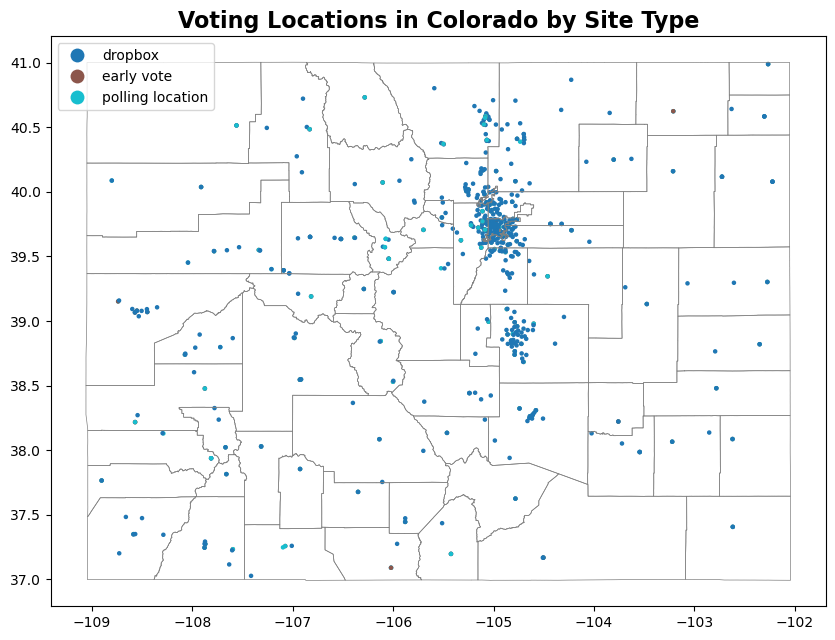

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot county boundaries
counties.boundary.plot(ax=ax, linewidth=0.5, color="gray")

# Plot voting locations
gdf.plot(
    ax=ax,
    column="site_type",
    legend=True,
    markersize=5
)

plt.title("Voting Locations in Colorado by Site Type", fontweight="bold", fontsize=16)
# option to save map
#plt.savefig('results/all_colorado_voting_locations.png')
plt.show()


In [34]:
gdf["site_type"].value_counts()

site_type
dropbox             467
polling location    152
early vote          148
Name: count, dtype: int64

In [44]:
gdf["county"].nunique()

64

In [45]:
gdf.isnull().sum()


X                    0
Y                    0
county               0
site_type            0
geocoded_address     0
population           0
registered voters    0
democrat             0
republican           0
other                0
total votes          0
geometry             0
dtype: int64

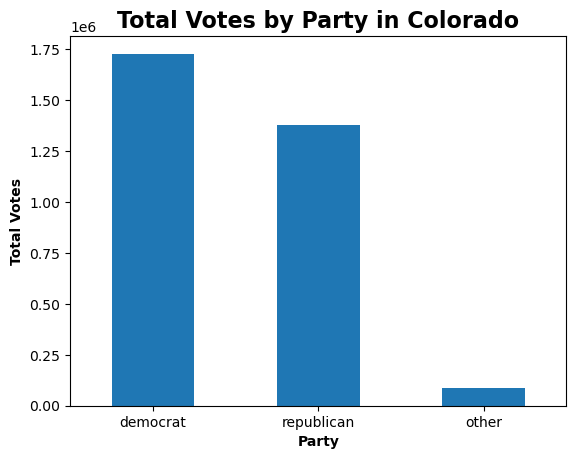

In [24]:

totals = votes_df[["democrat", "republican", "other"]].sum()

plt.figure()
totals.plot(kind="bar")

plt.title("Total Votes by Party in Colorado", weight="bold", fontsize=16)
plt.xlabel("Party", weight="bold")
plt.ylabel("Total Votes", weight="bold")

plt.xticks(rotation=0)
# option to save plot
#plt.savefig("results/colorado_total_votes_2024.png")
plt.show()


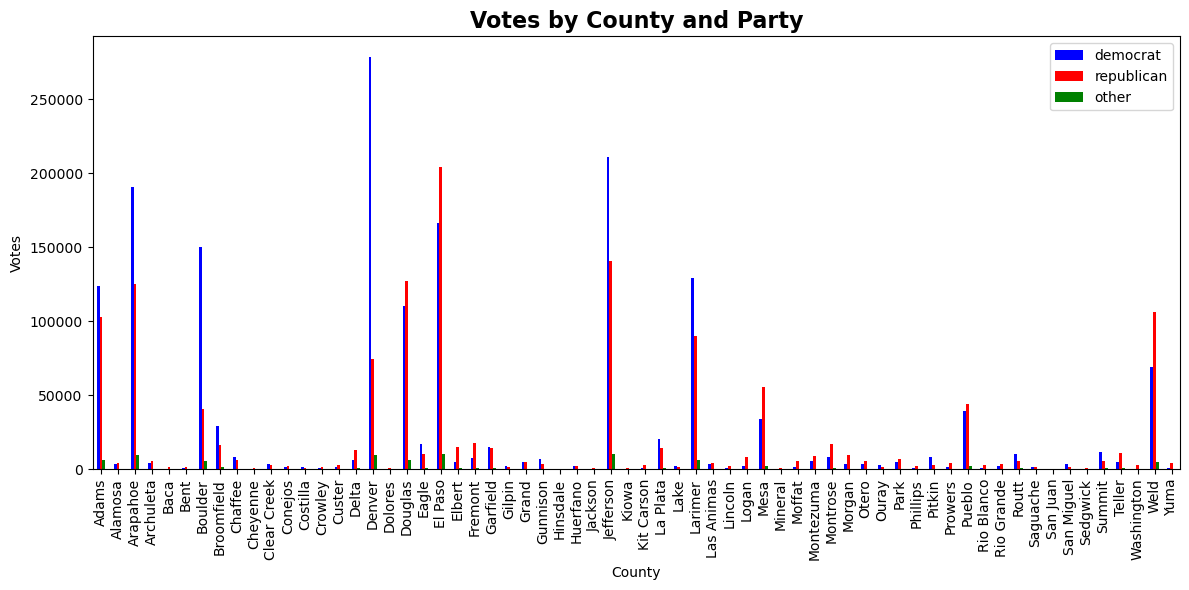

In [31]:
county_votes = votes_df.set_index("county")[["democrat", "republican", "other"]]
colors = ["blue", "red", "green"]
county_votes.plot(kind="bar", figsize=(12,6), color=colors)

plt.title("Votes by County and Party", weight="bold", fontsize=16)
plt.xlabel("County")
plt.ylabel("Votes")

plt.xticks(rotation=90)
plt.tight_layout()
# option to save plot
#plt.savefig("results/colorado_county_total_votes_2024.png")
plt.show()


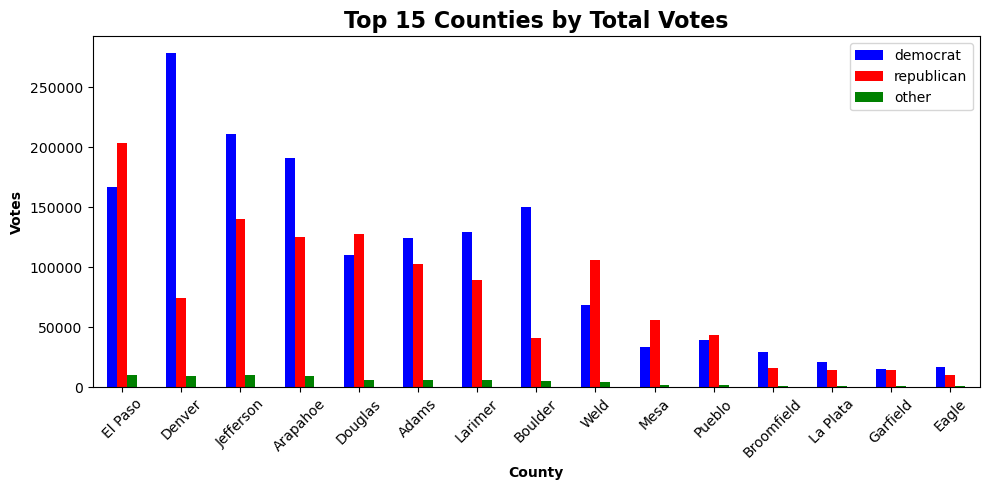

In [29]:
top_counties = votes_df.sort_values("total votes", ascending=False).head(15)

colors = ["blue", "red", "green"]

top_counties.set_index("county")[["democrat", "republican", "other"]].plot(
    kind="bar", figsize=(10,5), color=colors
)

plt.title("Top 15 Counties by Total Votes", weight="bold", fontsize=16)
plt.xlabel("County", weight="bold")
plt.ylabel("Votes", weight="bold")

plt.xticks(rotation=45)
plt.tight_layout()
# option to save plot
#plt.savefig("results/colorado_top_counties_total_votes_2024.png")
plt.show()


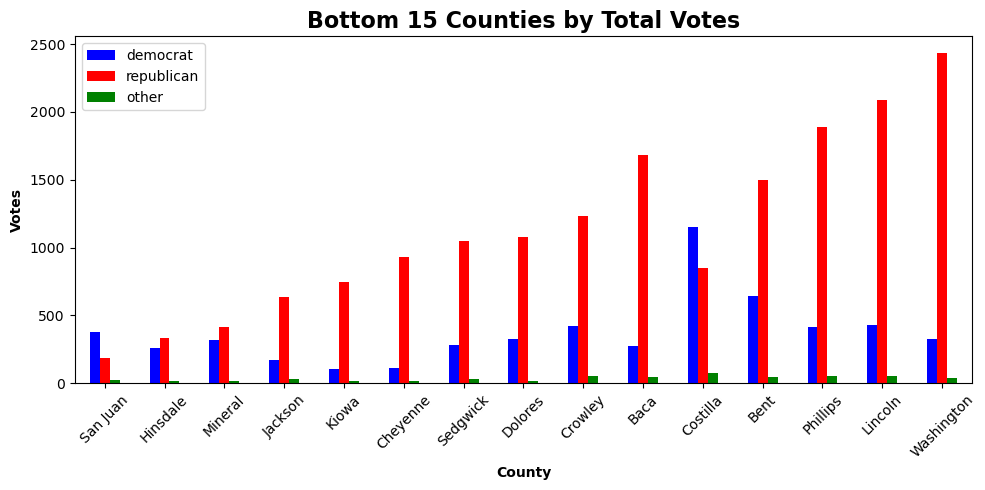

In [30]:
bottom_counties = votes_df.sort_values("total votes", ascending=True).head(15)

colors = ["blue", "red", "green"]

bottom_counties.set_index("county")[["democrat", "republican", "other"]].plot(
    kind="bar", figsize=(10,5), color=colors
)

plt.title("Bottom 15 Counties by Total Votes", weight="bold", fontsize=16)
plt.xlabel("County", weight="bold")
plt.ylabel("Votes", weight="bold")

plt.xticks(rotation=45)
plt.tight_layout()
# option to save plot
#plt.savefig("results/colorado_bottom_counties_total_votes_2024.png")
plt.show()

In [ ]:
# Normalize by population
vote_share = votes_df.copy()

vote_share["dem_share"] = vote_share["democrat"] / vote_share["total votes"]
vote_share["rep_share"] = vote_share["republican"] / vote_share["total votes"]
vote_share["other_share"] = vote_share["other"] / vote_share["total votes"]

vote_share.set_index("county")[["dem_share", "rep_share", "other_share"]].plot(
    kind="bar", figsize=(12,6)
)

plt.title("Vote Share by County")
plt.xlabel("County")
plt.ylabel("Proportion")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()